# Imports

In [34]:
import qcontrol.snv120.hamiltonian as qh
import qcontrol.snv120.hamiltonian_jax as qh_jax
import qcontrol.snv120.hamiltonian_jqt as qh_jqt
import qcontrol.snv120.parameters as params
import numpy as np
import jax.numpy as jnp
from matplotlib import pyplot as plt
from scipy.constants import c
from pydantic import BaseModel, Field
from typing import NamedTuple, Any, Dict
from abc import ABC, abstractmethod
from datetime import datetime
import jaxquantum as jqt
import jax
from typing import Callable
import time

LEVEL_OFFSET = 483796.026775 + params.L_exc/2
GAMMA_FREQ = 483796.026775 + params.L/2-2

# Modeling and differentiation

In [36]:
params_solve_hamiltonian = {
    'B' : 1,
    'theta' : 0,
    'phi' : 0,
    'q' : 0,
    'A' : jnp.ones((3,3)),
    'Ax' : jnp.ones((3,3)),
    'Ay' : jnp.zeros((3,3)),
    'L' : 0,
    'alpha' : 1,
    'beta' : 2,
}
E, Eref, U, Ustates, alignment = qh.solve_hamiltonian(**params_solve_hamiltonian)
E_jax, Eref_jax, U_jax, alignment_jax = qh_jax.solve_hamiltonian(**params_solve_hamiltonian)
E_jqt, Eref_jqt, U_jqt, Ustates_jqt, alignment_jqt = qh_jqt.solve_hamiltonian(**params_solve_hamiltonian)

print(E)
print(np.all(np.isclose(E_jqt, E_jax)))
print(np.all(np.isclose(Eref_jqt, Eref_jax)))

[[-3.15545502 -2.75404993 -1.92592079 -1.52522242  0.92793728  1.46620902
   3.21313218  3.75336968]]
True
True


In [65]:
params_ple_transitions = {
    'B' : 0,
    'theta' : 0,
    'phi' : 0,
    'eta' : jnp.array([0, 0, 1]),
    'alpha' : 0,
    'beta' : 0,
    'alpha_exc' : 0,
    'beta_exc' : 0,
    'A_gnd' : jnp.zeros((3,3)),
    'Ax_gnd' : jnp.zeros((3,3)),
    'Ay_gnd' : jnp.zeros((3,3)),
    'A_exc' : jnp.zeros((3,3)),
    'Ax_exc' : jnp.zeros((3,3)),
    'Ay_exc' : jnp.zeros((3,3)),
}

E, Eref, U, alignment, E_exc, Eref_exc, U_exc, alignment_exc, transition, cyclicity = qh.PLE_transitions(**params_ple_transitions)
E_jax, Eref_jax, U_jax, alignment_jax, E_exc_jax, Eref_exc_jax, U_exc_jax, alignment_exc_jax, transition_jax, cyclicity_jax = qh_jax.PLE_transitions(**params_ple_transitions)
E_jqt, Eref_jqt, U_jqt, alignment_jqt, E_exc_jqt, Eref_exc_jqt, U_exc_jqt, alignment_exc_jqt, transition_jqt, cyclicity_jqt = qh_jqt.PLE_transitions(**params_ple_transitions)

print(transition_jqt)
print(np.all(np.isclose(E, E_jqt)))
print(np.all(np.isclose(Eref, Eref_jqt)))
# print(np.all(np.isclose(U, U_jax, rtol=1)))
print(np.all(np.isclose(alignment, alignment_jqt)))
print(np.all(np.isclose(E_exc, E_exc_jqt)))
print(np.all(np.isclose(Eref_exc, Eref_exc_jqt)))
print(np.all(np.isclose(transition, transition_jqt)))
print(np.all(np.isclose(cyclicity, cyclicity_jqt)))
# print(np.all(np.isclose(U_exc, U_exc_jax)))

print(np.shape(cyclicity))
print(np.shape(E))
print(np.shape(Eref))

[[4. 0. 0. 0. 0. 0. 0. 0.]
 [0. 4. 0. 0. 0. 0. 0. 0.]
 [0. 0. 4. 0. 0. 0. 0. 0.]
 [0. 0. 0. 4. 0. 0. 0. 0.]
 [0. 0. 0. 0. 4. 0. 0. 0.]
 [0. 0. 0. 0. 0. 4. 0. 0.]
 [0. 0. 0. 0. 0. 0. 4. 0.]
 [0. 0. 0. 0. 0. 0. 0. 4.]]
True
True
True
True
True
True
True
(1, 8, 8)
(1, 8)
(8,)


In [62]:
print(transition_jqt)

[[4. 0. 0. 0. 0. 0. 0. 0.]
 [0. 4. 0. 0. 0. 0. 0. 0.]
 [0. 0. 4. 0. 0. 0. 0. 0.]
 [0. 0. 0. 4. 0. 0. 0. 0.]
 [0. 0. 0. 0. 4. 0. 0. 0.]
 [0. 0. 0. 0. 0. 4. 0. 0.]
 [0. 0. 0. 0. 0. 0. 4. 0.]
 [0. 0. 0. 0. 0. 0. 0. 4.]]


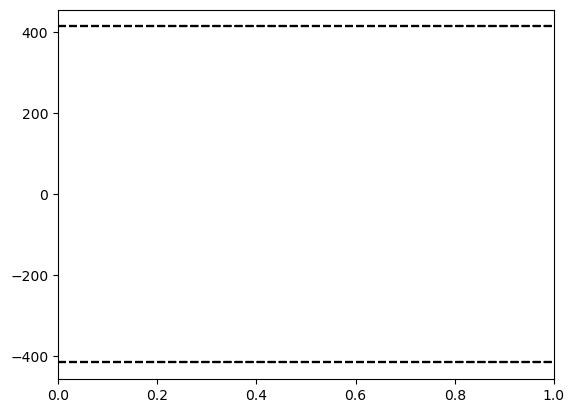

In [38]:
for E_single in E[0, :]:
    plt.axhline(E_single, color='black', linestyle='--')

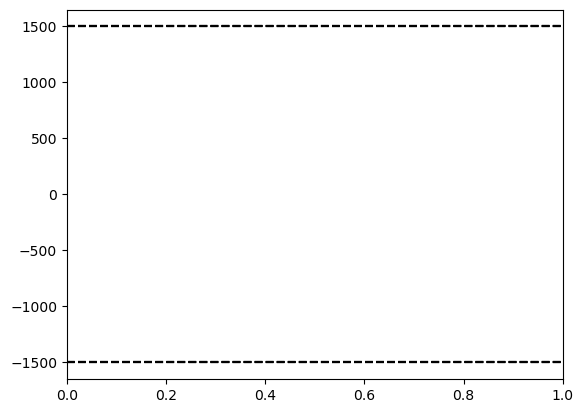

In [39]:
for E_single in E_exc[0, :]:
    plt.axhline(E_single, color='black', linestyle='--')

In [40]:
print(E_jax)

[-415.42647763 -415.42593244 -414.57647719 -414.57593201  414.42593244
  414.42647763  415.57593201  415.57647719]


In [41]:
f_ground_transition = (E_jax[:, None] - Eref_jax[0]) - (E_jax[None, :] - Eref_jax[0])
print("Ground MW Gamma Transitions")
print(f_ground_transition[:4,:4])

Ground MW Gamma Transitions
[[ 0.00000000e+00 -5.45183423e-04 -8.50000435e-01 -8.50545619e-01]
 [ 5.45183423e-04  0.00000000e+00 -8.49455252e-01 -8.50000435e-01]
 [ 8.50000435e-01  8.49455252e-01  0.00000000e+00 -5.45183423e-04]
 [ 8.50545619e-01  8.50000435e-01  5.45183423e-04  0.00000000e+00]]


In [42]:
f_ground_transition = (E_jax[:, None] - Eref_jax[0]) - (E_jax[None, :] - Eref_jax[0])
print("Ground MW Gamma Transitions")
print(f_ground_transition)

Ground MW Gamma Transitions
[[ 0.00000000e+00 -5.45183423e-04 -8.50000435e-01 -8.50545619e-01
  -8.29852410e+02 -8.29852955e+02 -8.31002410e+02 -8.31002955e+02]
 [ 5.45183423e-04  0.00000000e+00 -8.49455252e-01 -8.50000435e-01
  -8.29851865e+02 -8.29852410e+02 -8.31001864e+02 -8.31002410e+02]
 [ 8.50000435e-01  8.49455252e-01  0.00000000e+00 -5.45183423e-04
  -8.29002410e+02 -8.29002955e+02 -8.30152409e+02 -8.30152954e+02]
 [ 8.50545619e-01  8.50000435e-01  5.45183423e-04  0.00000000e+00
  -8.29001864e+02 -8.29002410e+02 -8.30151864e+02 -8.30152409e+02]
 [ 8.29852410e+02  8.29851865e+02  8.29002410e+02  8.29001864e+02
   0.00000000e+00 -5.45183423e-04 -1.14999956e+00 -1.15054475e+00]
 [ 8.29852955e+02  8.29852410e+02  8.29002955e+02  8.29002410e+02
   5.45183423e-04  0.00000000e+00 -1.14945438e+00 -1.14999956e+00]
 [ 8.31002410e+02  8.31001864e+02  8.30152409e+02  8.30151864e+02
   1.14999956e+00  1.14945438e+00  0.00000000e+00 -5.45183423e-04]
 [ 8.31002955e+02  8.31002410e+02  8.3015

In [43]:
f_exc_transition = (E_exc_jax[:, None] - Eref_exc_jax[0]) - (E_exc_jax[None, :] - Eref_exc_jax[0])
print("Excited MW Gamma Transitions")
print(f_exc_transition[:4,:4]*1e3)

Excited MW Gamma Transitions
[[ 0.00000000e+00 -5.45183423e-01 -9.63500819e+02 -9.64046003e+02]
 [ 5.45183423e-01  0.00000000e+00 -9.62955636e+02 -9.63500819e+02]
 [ 9.63500819e+02  9.62955636e+02  0.00000000e+00 -5.45183423e-01]
 [ 9.64046003e+02  9.63500819e+02  5.45183423e-01  0.00000000e+00]]


In [44]:
f_transition = (E_exc_jax[:, None] - Eref_exc_jax[0]) - (E_jax[None, :] - Eref_jax[0])
print("Gamma Transitions")
print(f_transition[:4,:4])
print(transition_jax[:4,:4])


Gamma Transitions
[[-0.09008315 -0.09062833 -0.94008358 -0.94062877]
 [-0.08953796 -0.09008315 -0.9395384  -0.94008358]
 [ 0.87341767  0.87287249  0.02341724  0.02287205]
 [ 0.87396286  0.87341767  0.02396242  0.02341724]]
[[3.99944778 0.         0.         0.        ]
 [0.         3.99944778 0.         0.        ]
 [0.         0.         3.99944618 0.        ]
 [0.         0.         0.         3.99944618]]


In [45]:
import jax
import jax.numpy as jnp
import optax
import numpy as np

jax.config.update("jax_enable_x64", True)

constant_params = {
    "B": 0.0,
    "theta": 0.0,
    "phi": 0.0,
    "eta": jnp.array([1.0, 0.5, 1.0]),

    "A_gnd": jnp.zeros((3, 3)),
    "Ax_gnd": jnp.zeros((3, 3)),
    "Ay_gnd": jnp.zeros((3, 3)),

    "A_exc": jnp.zeros((3, 3)),
    "Ax_exc": jnp.zeros((3, 3)),
    "Ay_exc": jnp.zeros((3, 3)),
}


def unpack_x(x):
    return {
        "alpha": x[0],
        "beta": x[1],
        "alpha_exc": x[2],
        "beta_exc": x[3],
    }


def get_f_transition_one(x):
    params = {
        **constant_params,
        **unpack_x(x),
    }

    (
        E,
        Eref,
        U,
        alignment,
        E_exc,
        Eref_exc,
        U_exc,
        alignment_exc,
        transition,
        cyclicity,
    ) = qh_jax.PLE_transitions(**params)

    f_transition = (
        (E_exc[:, None] - Eref_exc[0])
        - (E[None, :] - Eref[0])
    )

    return f_transition, transition


def gamma_prediction_one(x):
    f_transition, _transition = get_f_transition_one(x)
    return jnp.diag(f_transition[:4, :4])


def loss_one(x):
    gamma_pred = gamma_prediction_one(x)
    return jnp.mean((gamma_pred - gamma_target) ** 2)


In [46]:

optimizer = optax.chain(
    optax.clip_by_global_norm(10.0),
    optax.adam(learning_rate=10),
)

# x = [alpha, beta, alpha_exc, beta_exc]
# x0 shape: (N, 4)
key = jax.random.key(42)
x0 = jax.random.normal(key, shape=(40, 4), dtype=jnp.float64) * 50.0

gamma_target = jnp.array([-0.05, -0.05, 0.05, 0.05], dtype=jnp.float64)

def train_step_one(x, opt_state):
    loss, grads = jax.value_and_grad(loss_one)(x)
    updates, opt_state = optimizer.update(grads, opt_state, x)
    x = optax.apply_updates(x, updates)
    return x, opt_state, loss


train_step_many = jax.jit(jax.vmap(train_step_one, in_axes=(0, 0), out_axes=(0, 0, 0)))

# One independent Adam state per initial condition
opt_states = jax.vmap(optimizer.init)(x0)

n_steps = 5000

for step in range(n_steps):
    x0, opt_states, losses = train_step_many(x0, opt_states)

    if step % 250 == 0:
        best_idx = int(jnp.argmin(losses))
        print(
            f"step {step:5d} | "
            f"best loss={float(losses[best_idx]):.6e} | "
            f"best x={np.array(x0[best_idx])} | "
            f"best gamma={np.array(gamma_prediction_one(x0[best_idx]))}"
        )

# Convert back to shape (4, N)
final_losses = jax.vmap(loss_one)(x0)
final_gammas = jax.vmap(gamma_prediction_one)(x0)

best_idx = int(jnp.argmin(final_losses))
best_x = x0[best_idx]

print("\nFinal optimized parameters, shape (N, 4):")
print(np.array(x0))

print("\nFinal losses, shape (N,):")
print(np.array(final_losses))

print("\nFinal gammas, shape (N, 4):")
print(np.array(final_gammas))

print("\nBest initial-condition index:")
print(best_idx)

print("\nBest parameters [alpha, beta, alpha_exc, beta_exc]:")
print(np.array(best_x))

print("\nBest gamma prediction:")
print(np.array(gamma_prediction_one(best_x)))

print("\nTarget:")
print(np.array(gamma_target))

step     0 | best loss=2.711426e-03 | best x=[116.38325756 -24.1117394   45.90249581 -17.06130693] | best gamma=[0.57692593 0.57692593 0.57692593 0.57692593]
step   250 | best loss=2.500000e-03 | best x=[186.78188906  -3.52639727 -59.23273475   6.4045776 ] | best gamma=[1.07625738e-07 1.07625738e-07 1.07626022e-07 1.07626022e-07]
step   500 | best loss=2.500000e-03 | best x=[-128.85633799    3.65554115   92.10116845   -6.79807555] | best gamma=[1.64845915e-12 1.64845915e-12 1.53477231e-12 1.53477231e-12]
step   750 | best loss=2.500000e-03 | best x=[-38.76708624 -26.61435216 -57.10129877 -50.48841717] | best gamma=[-1.19371180e-12 -1.19371180e-12 -1.25055521e-12 -1.25055521e-12]
step  1000 | best loss=2.500000e-03 | best x=[184.97484906  -4.16683345  22.7957983   -7.57137634] | best gamma=[-7.95807864e-13 -7.95807864e-13 -9.09494702e-13 -9.09494702e-13]
step  1250 | best loss=2.500000e-03 | best x=[  1.89010454  43.69492396 -15.25701549 -82.9904664 ] | best gamma=[-5.68434189e-14 -5.68

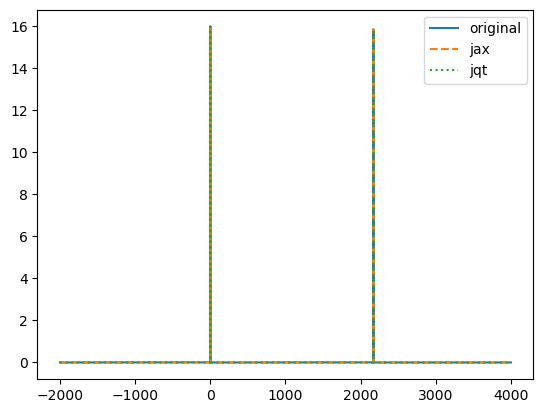

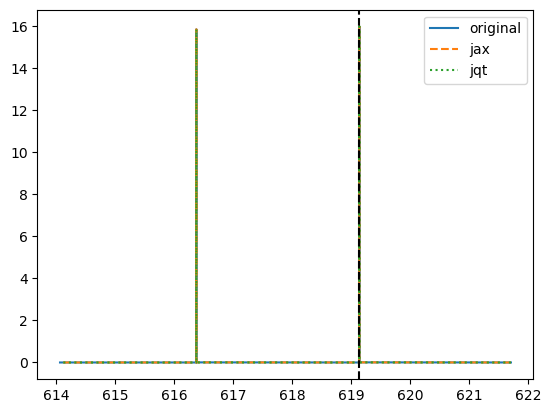

In [59]:
offset = 483796.026775 + params.L/2
laser_freq = offset + 1

params_ple_spectrum = {
    'f_meas' : jnp.linspace(-2e3, 4e3, 1000000),
    'intensity' : 1,
    'lw' : 0.04,
    'B' : 0,
    'theta' : 0,
    'phi' : 0,
    'eta' : jnp.array([0, 0, 1]),
    'alpha' : 0,
    'beta' : 0,
    'alpha_exc' : 0,
    'beta_exc' : 0,
    'A_gnd' : jnp.zeros((3,3)),
    'Ax_gnd' : jnp.zeros((3,3)),
    'Ay_gnd' : jnp.zeros((3,3)),
    'A_exc' : jnp.zeros((3,3)),
    'Ax_exc' : jnp.zeros((3,3)),
    'Ay_exc' : jnp.zeros((3,3)),
}

ple_spectrum = qh.PLE_spectrum(**params_ple_spectrum)
ple_spectrum_jax = qh_jax.PLE_spectrum(**params_ple_spectrum)
ple_spectrum_jqt = qh_jqt.PLE_spectrum(**params_ple_spectrum)

plt.figure()
plt.plot(params_ple_spectrum['f_meas'], ple_spectrum, label='original')
plt.plot(params_ple_spectrum['f_meas'], ple_spectrum_jax, linestyle='--', label='jax')
plt.plot(params_ple_spectrum['f_meas'], ple_spectrum_jqt, linestyle=':', label='jqt')
# plt.ylim(0, 1e-2)
plt.legend()
plt.show()

plt.figure()
plt.plot(c/(params_ple_spectrum['f_meas']+offset), ple_spectrum, label='original')
plt.plot(c/(params_ple_spectrum['f_meas']+offset), ple_spectrum_jax, linestyle='--', label='jax')
plt.plot(c/(params_ple_spectrum['f_meas']+offset), ple_spectrum_jqt, linestyle=':', label='jqt')
# plt.ylim(0, 1e-2)
plt.axvline(619.13, color='black', linestyle='--')
plt.legend()
plt.show()

# Theta Scheming

In [2]:
class Distribution(NamedTuple):
    weights: jnp.ndarray # N

In [ ]:
class SnV120Distribution(NamedTuple):
    """
    Theta_i (0 < i < N) parameters for the SnV120 qubit.
    """
    weights: jnp.ndarray # N
    # Energy level and cyclicity parameters
    B_settings:    jnp.ndarray # (N, 3) digital vector magnet axes settings, units of Tesla
    B_axes_factor: jnp.ndarray # (N, 3) error in vector magnet axes magnitude
    B_axes_angles: jnp.ndarray # (N, 3, 2) vector magnet axes angles (theta, phi) relative to the dipole axis

    # Hamiltonian Parameters
    alpha:       jnp.ndarray # N
    beta:        jnp.ndarray # N
    alpha_exc:   jnp.ndarray # N
    beta_exc:    jnp.ndarray # N
    A_gnd:       jnp.ndarray # (N, 3, 3)
    Ax_gnd:      jnp.ndarray # (N, 3, 3)
    Ay_gnd:      jnp.ndarray # (N, 3, 3)
    A_exc:       jnp.ndarray # (N, 3, 3)
    Ax_exc:      jnp.ndarray # (N, 3, 3)
    Ay_exc:      jnp.ndarray # (N, 3, 3)
    # rg:          jnp.ndarray # N
    # upsilon_gnd: jnp.ndarray # N
    # upsilon_exc: jnp.ndarray # N

    # Excited state lifetime
    excited_state_lifetime: jnp.ndarray # N or 1, in units of nanoseconds

    # Collection Efficiency Parameters
    debye_waller_factor:  jnp.ndarray # N or 1
    quantum_efficiency:   jnp.ndarray # N or 1
    optical_transmission: jnp.ndarray # N or 1
    dark_count_rate:      jnp.ndarray # N or 1

    # Resonant pump coupling
    resonant_pump_coupling_rate: jnp.ndarray # N, in units of coupling rate, or Hz
    resonant_pump_polarization:  jnp.ndarray # (N, 2) or (2) optimal possible polarization relative to the dipole moment (theta, phi)
    waveplate_angles:            jnp.ndarray # (N, M), for M waveplates, in units of degrees, range [0, 360)

    # Transmission line dynamic B field
    mw_B_orientation: jnp.ndarray # (N, 2), transmission line B field orientation (theta, phi) relative to the dipole axis
    mw_B_magnitude:   jnp.ndarray # N, in units of Tesla

    # Drift and diffusion
    spectral_diffusion_rate: jnp.ndarray # N, in units of Hz/sqrt(s)
    polarization_drift_rate: jnp.ndarray # N, in units of rads/sqrt(s)

    # Physical constants
    mu_B_GHz_per_T = 13.996 # [GHz/T]
    g_e = 2.0

    # Helper functions
    def get_B_cartesian(self, idx=...):
        """
        Returns shape (N, 3), in units of Tesla, or scalar if idx selects a single.
        """
        theta = self.B_axes_angles[idx, :, 0]
        phi = self.B_axes_angles[idx, :, 1]

        B_axes_orientations = jnp.stack([
            jnp.sin(theta) * jnp.cos(phi),
            jnp.sin(theta) * jnp.sin(phi),
            jnp.cos(theta),
        ], axis=-1)

        return jnp.sum(
            self.B_settings[idx, :, None]
            * self.B_axes_factor[idx, :, None]
            * B_axes_orientations,
            axis=-2,
        )

    def get_B_mag(self, idx=...):
        """
            Returns shape (N,), in units of GHz, or scalar if idx selects a single.
        """
        B = self.get_B_cartesian(idx)
        return jnp.linalg.norm(B * self.mu_B_GHz_per_T * self.g_e, axis=-1)
    
    def get_B_theta(self, idx=...):
        """
        Theta is the polar angle of vector magnet axes with the dipole axis as the polar axis.
        Returns shape (N,), in radians, range [0, pi], or scalar if idx selects a single.
        """
        B = self.get_B_cartesian(idx)
        B_perp = jnp.linalg.norm(B[..., :2], axis=-1)
        theta = jnp.arctan2(B_perp, B[..., 2])
        return theta

    def get_B_phi(self, idx=...):
        """
        Phi is the azimuthal angle of vector magnet axes around the dipole axis.
        Returns shape (N,), in radians, range (-pi, pi], or scalar if idx selects a single.
        """
        B = self.get_B_cartesian(idx)
        phi = jnp.arctan2(B[..., 1], B[..., 0])
        return phi

    def get_eta(self, idx=...):
        """
            Returns shape (N, 3), in units of the dipole moment, or scalar if idx selects a single.
        """
        return jnp.asarray(
            [
                jnp.sin(self.resonant_pump_polarization[idx, 0])
                * jnp.cos(self.resonant_pump_polarization[idx, 1]),
                jnp.sin(self.resonant_pump_polarization[idx, 0])
                * jnp.sin(self.resonant_pump_polarization[idx, 1]),
                jnp.cos(self.resonant_pump_polarization[idx, 0]),
            ]
        )
    def scattering_rate(self, idx=...):
        """
        Returns the scattering rate of photons from the excited state under a full power resonant pump.
        """
        numerator = self.resonant_pump_coupling_rate[idx]**2/self.excited_state_lifetime[idx]
        denominator = 1/self.excited_state_lifetime[idx]**2+ 2 * self.resonant_pump_coupling_rate[idx]**2
        return numerator/denominator

    @jax.jit(static_argnames=["ground_state"])
    def solve_hamiltonian_batch(self, idx, ground_state=True):
        if ground_state:
            return jax.vmap(qh_jqt.solve_hamiltonian,
                in_axes=(0, 0, 0, None, 0, 0, 0, None, 0, 0))(
                self.get_B_mag(idx),
                self.get_B_theta(idx),
                self.get_B_phi(idx),
                params.q,
                self.A_gnd[idx],
                self.Ax_gnd[idx],
                self.Ay_gnd[idx],
                params.L,
                self.alpha[idx],
                self.beta[idx],
            )
        else:
            return jax.vmap(qh_jqt.solve_hamiltonian,
                in_axes=(0, 0, 0, None, 0, 0, 0, None, 0, 0))(
                self.get_B_mag(idx),
                self.get_B_theta(idx),
                self.get_B_phi(idx),
                params.q_exc,
                self.A_exc[idx],
                self.Ax_exc[idx],
                self.Ay_exc[idx],
                params.L_exc,
                self.alpha_exc[idx],
                self.beta_exc[idx],
            )

    @jax.jit(static_argnames=["ground_state"])
    def solve_hamiltonian_all(self, ground_state=True):
        if ground_state:
            return jax.vmap(qh_jqt.solve_hamiltonian,
                in_axes=(0, 0, 0, None, 0, 0, 0, None, 0, 0))(
                self.get_B_mag(),
                self.get_B_theta(),
                self.get_B_phi(),
                params.q,
                self.A_gnd,
                self.Ax_gnd,
                self.Ay_gnd,
                params.L,
                self.alpha,
                self.beta,
            )
        else:
            return jax.vmap(qh_jqt.solve_hamiltonian,
                in_axes=(0, 0, 0, None, 0, 0, 0, None, 0, 0))(
                self.get_B_mag(),
                self.get_B_theta(),
                self.get_B_phi(),
                params.q_exc,
                self.A_exc,
                self.Ax_exc,
                self.Ay_exc,
                params.L_exc,
                self.alpha_exc,
                self.beta_exc,
            )
    def solve_hamiltonian(self, idx=0, ground_state=True):
        if idx is ...:
            return self.solve_hamiltonian_all(ground_state)
        elif isinstance(idx, jnp.ndarray):
            return self.solve_hamiltonian_batch(idx, ground_state)
        if ground_state:
            return qh_jqt.solve_hamiltonian(
                self.get_B_mag(idx),
                self.get_B_theta(idx),
                self.get_B_phi(idx),
                params.q,
                self.A_gnd[idx],
                self.Ax_gnd[idx],
                self.Ay_gnd[idx],
                params.L,
                self.alpha[idx],
                self.beta[idx],
            )
        else:   
            return qh_jqt.solve_hamiltonian(
                self.get_B_mag(idx),
                self.get_B_theta(idx),
                self.get_B_phi(idx),
                params.q_exc,
                self.A_exc[idx],
                self.Ax_exc[idx],
                self.Ay_exc[idx],
                params.L_exc,
                self.alpha_exc[idx],
                self.beta_exc[idx],
            )

    @jax.jit
    def get_all_cyclicity(self):
        return jax.vmap(qh_jqt.calculate_spontaneous_cyclicity,
            in_axes=(0,0,0,0,0,0,0,0,0,0,0,0,0,None))(
            self.get_B_mag(),
            self.get_B_theta(),
            self.get_B_phi(),
            alpha=self.alpha,
            beta=self.beta,
            alpha_exc=self.alpha_exc,
            beta_exc=self.beta_exc,
            A_gnd=self.A_gnd,
            Ax_gnd=self.Ax_gnd,
            Ay_gnd=self.Ay_gnd,
            A_exc=self.A_exc,
            Ax_exc=self.Ax_exc,
            Ay_exc=self.Ay_exc,
            included_states=None,
        )

    @jax.jit
    def get_cyclicity_batch(self, idx):
        return jax.vmap(qh_jqt.calculate_spontaneous_cyclicity,
            in_axes=(0,0,0,0,0,0,0,0,0,0,0,0,0,None))(
            self.get_B_mag(idx),
            self.get_B_theta(idx),
            self.get_B_phi(idx),
            alpha=self.alpha[idx],
            beta=self.beta[idx],
            alpha_exc=self.alpha_exc[idx],
            beta_exc=self.beta_exc[idx],
            A_gnd=self.A_gnd[idx],
            Ax_gnd=self.Ax_gnd[idx],
            Ay_gnd=self.Ay_gnd[idx],
            A_exc=self.A_exc[idx],
            Ax_exc=self.Ax_exc[idx],
            Ay_exc=self.Ay_exc[idx],
            included_states=None,
        )

    def get_cyclicity(self, idx=...):
        if idx is ...:
            return self.get_all_cyclicity()
        elif isinstance(idx, jnp.ndarray):
            return self.get_cyclicity_batch(idx)
        return qh_jqt.calculate_spontaneous_cyclicity(
            self.get_B_mag(idx),
            self.get_B_theta(idx),
            self.get_B_phi(idx),
            alpha=self.alpha[idx],
            beta=self.beta[idx],
            alpha_exc=self.alpha_exc[idx],
            beta_exc=self.beta_exc[idx],
            A_gnd=self.A_gnd[idx],
            Ax_gnd=self.Ax_gnd[idx],
            Ay_gnd=self.Ay_gnd[idx],
            A_exc=self.A_exc[idx],
            Ax_exc=self.Ax_exc[idx],
            Ay_exc=self.Ay_exc[idx],
            included_states=None,
            )

    def get_ple_freqs(self, idx=...):
        E, Eref, U, U_states, alignment = self.solve_hamiltonian(idx=idx, ground_state=True)
        E_exc, Eref_exc, U_exc, U_exc_states, alignment_exc = self.solve_hamiltonian(idx=idx, ground_state=False)
        # Calculate spin preserving ground orbital transition frequencies
        f_transitions = E_exc[..., :4] - E[..., :4] + LEVEL_OFFSET
        return f_transitions

    def get_emr_freqs(self, idx=...):
        """
        Returns the electron magnetic resonance frequencies.
        """
        E, Eref, U, U_states, alignment = self.solve_hamiltonian(idx=idx, ground_state=True)
        emr_freqs = jnp.array([E[..., 2]-E[..., 0], E[..., 3]-E[..., 1]])
        return emr_freqs

    def get_nmr_freqs(self, idx=...):
        """
        Returns the nuclear magnetic resonance frequencies.
        """
        E, Eref, U, U_states, alignment = self.solve_hamiltonian(idx=idx, ground_state=True)
        nmr_freqs = jnp.array([E[..., 1]-E[..., 0], E[..., 3]-E[..., 2]])
        return nmr_freqs
    
    def get_init_timestep(self, idx=0, electron_state=0, nuclear_state=None, decay_target=0.001):
        if nuclear_state is None:
            pump_state = 1-electron_state
            excitation_freqs = self.get_ple_freqs()[2*(pump_state):(2*(pump_state+1))]


In [4]:
class ExperimentResult(NamedTuple):
    experiment: str
    parameters: Dict[str, Any]
    result: Any
    time: datetime

In [33]:
x = jnp.linspace(1,9,9).reshape(3,3)
print(x[..., 2])

[3. 6. 9.]


In [6]:
# class RFSoC120Experiment(Experiment):
#     def _model(self, distribution: Distribution, sample_i: int, assumed_true_i: int):
#         pass

#     def _sample(self, distribution: Distribution, sample_i: int):
#         pass

    
#     # @abstractmethod
#     # def _

In [7]:
# class Experimentalist():
#     distribution: Distribution
#     experiments: list[Experiment]
#     experiment_history: list[ExperimentResult]

#     def __init__(self, distribution: Distribution, experiments: list[Experiment]):
#         self.distribution = distribution
#         self.experiments = experiments

#     def get_weights(self):
#         return self.distribution.weights
    
#     def estimate_eig(self, sample_i=None) -> list[float]:
#         """Returns the expected information gain (EIG) for each experiment."""
#         if sample_i is None:
#             sample_i = jnp.argmax(self.distribution.weights)

# Test Simulation

Time taken: 16.76942014694214 seconds


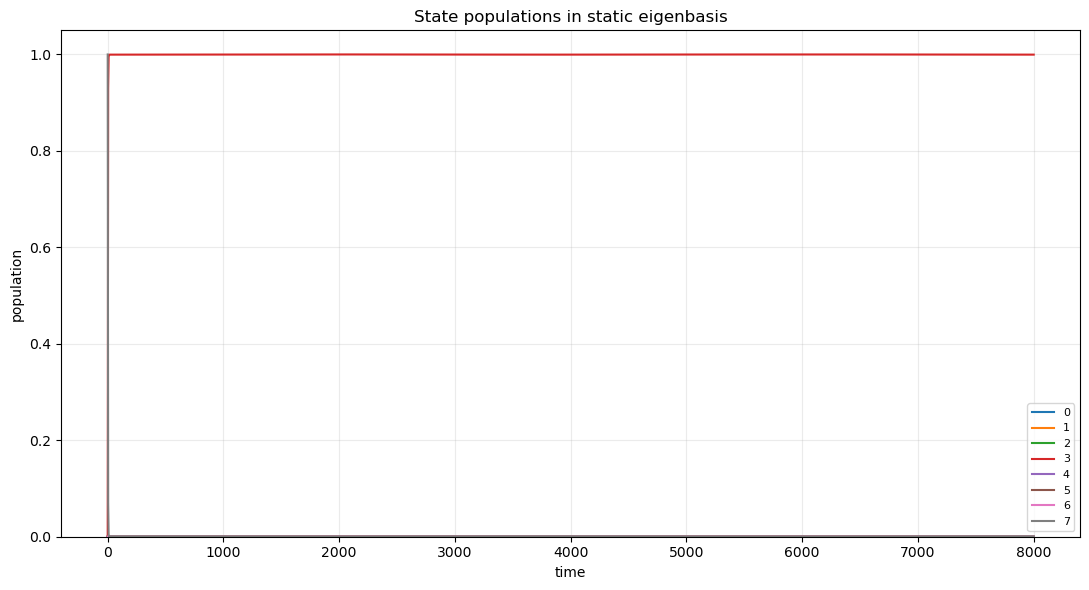

In [8]:
from qcontrol.snv120.snv_time_domain_mesolve import (
    make_real_cosine_signal,
    run_time_domain_mesolve,
    plot_state_populations,
)

tlist = jnp.linspace(0.0, 8000.0, 2000)  # choose units reciprocal to H
b_signal = make_real_cosine_signal(amplitude=1.0, omega=2 * jnp.pi * 0.010)(tlist)
optical_signal = make_real_cosine_signal(amplitude=0.02, omega=2 * jnp.pi * 0.250)(tlist)

level_offset = 483796.026775 + params.L_exc/2
laser_freq = 483796.026775 + params.L/2-2
excited_ground_split = level_offset - laser_freq
result = run_time_domain_mesolve(
    B=1.0,
    theta=0.0,
    phi=0.0,
    excited_ground_split=excited_ground_split,
    excited_state_lifetime=1,
    resonant_pump_polarization=jnp.array([jnp.pi / 2, 2.0]),
    B_drive_orientation=jnp.array([jnp.pi / 2, 0.0]),
    alpha=0.0,
    beta=0.0,
    alpha_exc=0.0,
    beta_exc=0.0,
    A_gnd=jnp.zeros((3,3)),
    Ax_gnd=jnp.zeros((3,3)),
    Ay_gnd=jnp.zeros((3,3)),
    A_exc=jnp.zeros((3,3)),
    Ax_exc=jnp.zeros((3,3)),
    Ay_exc=jnp.zeros((3,3)),
    upsilon_gnd=0.0,
    upsilon_exc=0.0,
    tlist=tlist,
    b_signal=b_signal,
    optical_signal=optical_signal,
    initial_flat_index=7,
    included_states=(0, 1, 2, 3),
    solver_options=jqt.SolverOptions.create(progress_meter=False),
)

start_time = time.time()
result = run_time_domain_mesolve(
    B=0.3,
    theta=0.0,
    phi=0.0,
    excited_ground_split=excited_ground_split,
    excited_state_lifetime=1,
    resonant_pump_polarization=jnp.array([0, 0]),
    B_drive_orientation=jnp.array([0, 0.0]),
    alpha=0.0,
    beta=0.0,
    alpha_exc=0.0,
    beta_exc=0.0,
    A_gnd=jnp.zeros((3,3)),
    Ax_gnd=jnp.zeros((3,3)),
    Ay_gnd=jnp.zeros((3,3)),
    A_exc=jnp.zeros((3,3)),
    Ax_exc=jnp.zeros((3,3)),
    Ay_exc=jnp.zeros((3,3)),
    upsilon_gnd=0.0,
    upsilon_exc=0.0,
    tlist=tlist,
    b_signal=b_signal,
    optical_signal=optical_signal,
    initial_flat_index=7,
    included_states=(0, 1, 2, 3),
    solver_options=jqt.SolverOptions.create(progress_meter=False),
)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")
fig, ax = plot_state_populations(result, basis="eigen", max_states=None)
plt.show()


In [30]:
print(result.H0)

Quantum array: dims = ((2, 4), (2, 4)), bdims = (), shape = (8, 8), type = oper, impl = dense
Qarray data =
[[-0.12758178+0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j -0.12741822+0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.12741822+0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.12758178+0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   1.85539322+0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  1.85555678+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.       

In [ ]:
N=1000

dist = SnV120Distribution(
    weights=jnp.ones((N))/N, # N

    B_settings=jnp.zeros((N, 3))+1/3/28, # (N, 3) physical vector magnet axes settings, units of Tesla
    B_axes_factor=jnp.ones((N, 3)), # (N, 3) error in vector magnet axes magnitude
    B_axes_angles=jnp.zeros((N, 3, 2)), # (N, 3, 2) vector magnet axes angles (theta, phi) relative to the dipole axis

    # Hamiltonian Parameters
    alpha=jnp.zeros((N)), # N
    beta=jnp.zeros((N)), # N
    alpha_exc=jnp.zeros((N)), # N
    beta_exc=jnp.zeros((N)), # N
    A_gnd=jnp.zeros((N, 3, 3)), # (N, 3, 3)
    Ax_gnd=jnp.zeros((N, 3, 3)), # (N, 3, 3)
    Ay_gnd=jnp.zeros((N, 3, 3)), # (N, 3, 3)
    A_exc=jnp.zeros((N, 3, 3)), # (N, 3, 3)
    Ax_exc=jnp.zeros((N, 3, 3)), # (N, 3, 3)
    Ay_exc=jnp.zeros((N, 3, 3)), # (N, 3, 3)
    # rg=jnp.zeros((N)), # N
    # upsilon_gnd=jnp.zeros((N)), # N
    # upsilon_exc=jnp.zeros((N)), # N

    # Excited state lifetime
    excited_state_lifetime=jnp.ones((N)), # N or 1, in units of nanoseconds

    # Collection Efficiency Parameters
    debye_waller_factor=jnp.ones((N)), # N or 1
    quantum_efficiency=jnp.ones((N)), # N or 1
    optical_transmission=jnp.ones((N)), # N or 1

    # Resonant pump coupling
    resonant_pump_coupling_rate=jnp.ones((N)), # N, in units of coupling rate, or Hz
    resonant_pump_polarization=jnp.ones((N, 2)), # (N, 2) optimal possible polarization relative to the dipole moment (theta, phi)
    waveplate_angles=jnp.ones((N, 3)), # (N, M), for M waveplates, in units of degrees, range [0, 360)

    # Transmission line dynamic B field
    mw_B_orientation=jnp.zeros((N, 2)), # (N, 2), transmission line B field orientation (theta, phi) relative to the dipole axis
    mw_B_magnitude=jnp.ones((N)), # N, in units of Tesla

    # Drift and diffusion
    spectral_diffusion_rate=jnp.zeros((N)), # N, in units of Hz/sqrt(s)
    polarization_drift_rate=jnp.zeros((N)), # N, in units of rads/sqrt(s)
)


tlist = jnp.tile(jnp.linspace(0.0, 8000.0, 1000), (N, 1))  # choose units reciprocal to H
save_tlist = jnp.tile(jnp.linspace(0.0, 20.0, 2), (N, 1))
b_signal = make_real_cosine_signal(amplitude=1.0, omega=2 * jnp.pi * 0.10)(tlist)
optical_signal = make_real_cosine_signal(amplitude=0.02, omega=2 * jnp.pi * 0.250)(tlist)

level_offset = 483796.026775 + params.L_exc/2
laser_freq = 483796.026775 + params.L/2-2
excited_ground_split = level_offset - laser_freq

def snv_mesolve(B, theta, phi, excited_ground_split, excited_state_lifetime, resonant_pump_polarization, B_drive_orientation, alpha, beta, alpha_exc, beta_exc, A_gnd, Ax_gnd, Ay_gnd, A_exc, Ax_exc, Ay_exc, upsilon_gnd, upsilon_exc, tlist, b_signal, optical_signal):
    return run_time_domain_mesolve(
        B=B,
        theta=theta,
        phi=phi,
        excited_ground_split=excited_ground_split,
        excited_state_lifetime=excited_state_lifetime,
        resonant_pump_polarization=resonant_pump_polarization,
        B_drive_orientation=B_drive_orientation,
        alpha=alpha,
        beta=beta,
        alpha_exc=alpha_exc,
        beta_exc=beta_exc,
        A_gnd=A_gnd,
        Ax_gnd=Ax_gnd,
        Ay_gnd=Ay_gnd,
        A_exc=A_exc,
        Ax_exc=Ax_exc,
        Ay_exc=Ay_exc,
        upsilon_gnd=upsilon_gnd,
        upsilon_exc=upsilon_exc,
        tlist=tlist,
        b_signal=b_signal,
        optical_signal=optical_signal,
        initial_flat_index=7,
        included_states=(0, 1, 2, 3),
        solver_options=jqt.SolverOptions.create(progress_meter=False),
    )

snv_vmap = jax.jit(jax.vmap(snv_mesolve))

results = snv_vmap(
    B=dist.get_B_GHz(),
    theta=dist.get_B_theta(),
    phi=dist.get_B_phi(),
    excited_ground_split=jnp.ones((N))*excited_ground_split,
    excited_state_lifetime=dist.excited_state_lifetime,
    resonant_pump_polarization=dist.resonant_pump_polarization,
    B_drive_orientation=dist.mw_B_orientation,
    alpha=dist.alpha,
    beta=dist.beta,
    alpha_exc=dist.alpha_exc,
    beta_exc=dist.beta_exc,
    A_gnd=dist.A_gnd,
    Ax_gnd=dist.Ax_gnd,
    Ay_gnd=dist.Ay_gnd,
    A_exc=dist.A_exc,
    Ax_exc=dist.Ax_exc,
    Ay_exc=dist.Ay_exc,
    upsilon_gnd=dist.upsilon_gnd,
    upsilon_exc=dist.upsilon_exc,
    tlist=tlist,
    b_signal=b_signal,
    optical_signal=optical_signal,
)

start_time = time.time()

results = snv_vmap(
    B=dist.get_B_GHz(),
    theta=dist.get_B_theta(),
    phi=dist.get_B_phi(),
    excited_ground_split=jnp.ones((N))*excited_ground_split,
    excited_state_lifetime=dist.excited_state_lifetime,
    resonant_pump_polarization=dist.resonant_pump_polarization,
    B_drive_orientation=dist.mw_B_orientation,
    alpha=dist.alpha,
    beta=dist.beta,
    alpha_exc=dist.alpha_exc,
    beta_exc=dist.beta_exc,
    A_gnd=dist.A_gnd,
    Ax_gnd=dist.Ax_gnd,
    Ay_gnd=dist.Ay_gnd,
    A_exc=dist.A_exc,
    Ax_exc=dist.Ax_exc,
    Ay_exc=dist.Ay_exc,
    upsilon_gnd=dist.upsilon_gnd,
    upsilon_exc=dist.upsilon_exc,
    tlist=tlist,
    b_signal=b_signal,
    optical_signal=optical_signal,
)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")


W0602 17:21:52.397415 1977084 hlo_rematerialization.cc:3233] Can't reduce memory use below 31.96GiB (34315713632 bytes) by rematerialization; only reduced to 48.98GiB (52592824227 bytes), down from 48.98GiB (52592824227 bytes) originally
